In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier,  XGBRegressor

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

import sentencepiece as spm
from accelerate import Accelerator

from xgboost import XGBClassifier

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("dataset/twitter_training_enhanced.csv")

print(df.shape)
df.head()

(74682, 11)


,tweet_id,entity,sentiment,tweet,followers,likes,comments,shares,posting_hour,platform,engagement
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,45080,5369,589,794,7,Reddit,0.1498
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,387091,21628,1325,1470,0,Twitter,0.0631
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,327458,16496,3596,345,19,Facebook,0.0624
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,219719,18669,1884,624,12,Twitter,0.0964
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,216791,10935,2594,200,10,Facebook,0.0633


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 74682
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tweet_id      74682 non-null  int64  
 1   entity        74682 non-null  str    
 2   sentiment     74682 non-null  str    
 3   tweet         73996 non-null  str    
 4   followers     74682 non-null  int64  
 5   likes         74682 non-null  int64  
 6   comments      74682 non-null  int64  
 7   shares        74682 non-null  int64  
 8   posting_hour  74682 non-null  int64  
 9   platform      74682 non-null  str    
 10  engagement    74682 non-null  float64
dtypes: float64(1), int64(6), str(4)
memory usage: 16.0 MB


In [5]:
df.isnull().sum()

tweet_id          0
entity            0
sentiment         0
tweet           686
followers         0
likes             0
comments          0
shares            0
posting_hour      0
platform          0
engagement        0
dtype: int64

In [6]:
df.fillna("Unknown", inplace=True)

,tweet_id,entity,sentiment,tweet,followers,likes,comments,shares,posting_hour,platform,engagement
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,45080,5369,589,794,7,Reddit,0.1498
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,387091,21628,1325,1470,0,Twitter,0.0631
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,327458,16496,3596,345,19,Facebook,0.0624
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,219719,18669,1884,624,12,Twitter,0.0964
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,216791,10935,2594,200,10,Facebook,0.0633
...,...,...,...,...,...,...,...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...,204491,9204,854,938,2,Twitter,0.0538
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...,214933,13783,1026,1763,22,Twitter,0.0771
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...,299163,22412,2673,337,21,Reddit,0.0850
74680,9200,Nvidia,Positive,Just realized between the windows partition of...,23806,2815,525,418,3,Instagram,0.1579


In [7]:
# =============================================
# BLOCK 2: DATA CLEANING
# =============================================

print("🔄 Starting Data Cleaning Pipeline...")

# 2. Text Cleaning Function
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions and hashtags symbols
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    return text

# Apply cleaning
df['clean_tweet'] = df['tweet'].apply(clean_text)

print("✅ Data Cleaning Completed!")
print(f"Sample cleaned tweet:\n{df['clean_tweet'].iloc[0]}")
print(f"\nTotal rows after cleaning: {len(df)}")

# Save cleaned version
df.to_csv("dataset/cleaned_twitter_data.csv", index=False)
print("💾 Cleaned dataset saved as 'cleaned_twitter_data.csv'")

🔄 Starting Data Cleaning Pipeline...


✅ Data Cleaning Completed!
Sample cleaned tweet:
im getting borderlands murder

Total rows after cleaning: 74682
💾 Cleaned dataset saved as 'cleaned_twitter_data.csv'


In [8]:
# # =============================================
# # BLOCK 2.5: LANGUAGE DETECTION
# # =============================================

# print("🌍 Starting Language Detection...")

# from langdetect import detect, DetectorFactory

# DetectorFactory.seed = 0  # For reproducibility

# def detect_language(text):
#     try:
#         if len(text.strip()) < 10:
#             return "en"
#         return detect(text)
#     except:
#         return "en"  # Default to English

# df['language'] = df['clean_tweet'].apply(detect_language)

# print("✅ Language Detection Completed")
# print(df['language'].value_counts().head(10))

📊 Starting Exploratory Data Analysis...
Total Posts: 74,682
Unique Entities/Brands: 32
Unique Platforms: 4
Unique Sentiments: 4


C:\Users\DELL\AppData\Local\Temp\ipykernel_6208\1582327249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


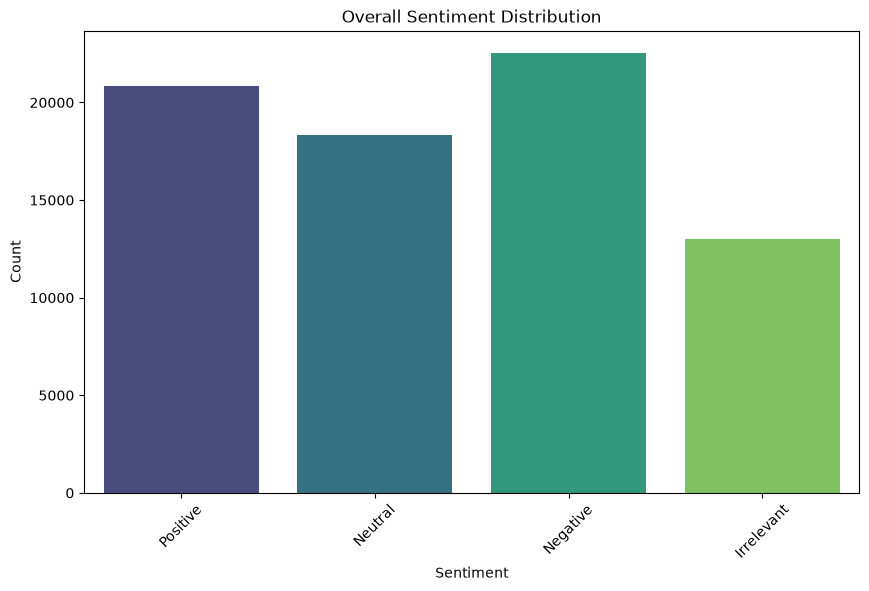

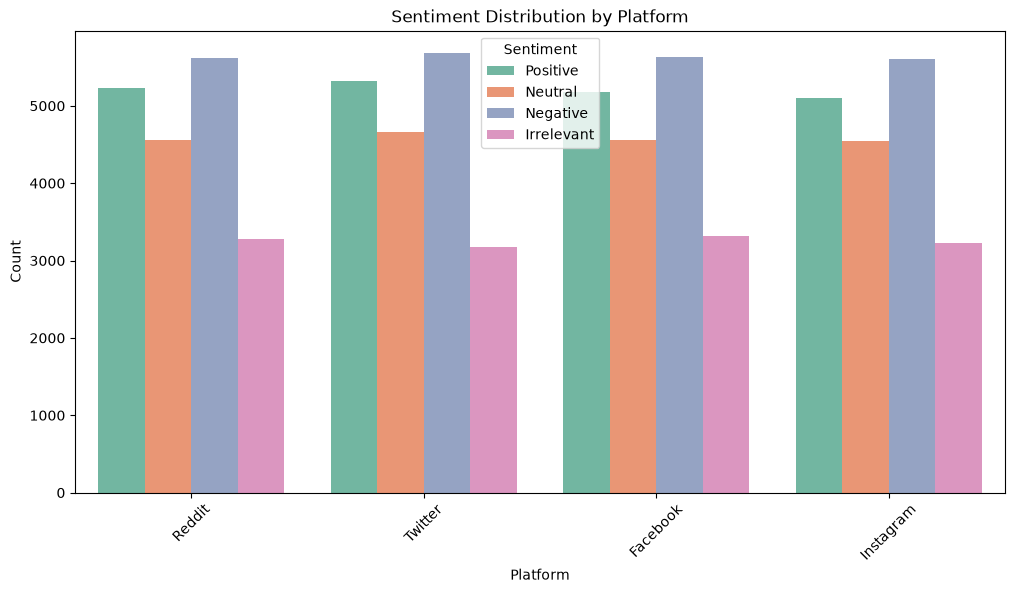

C:\Users\DELL\AppData\Local\Temp\ipykernel_6208\1582327249.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entities.values, y=top_entities.index, palette='magma')


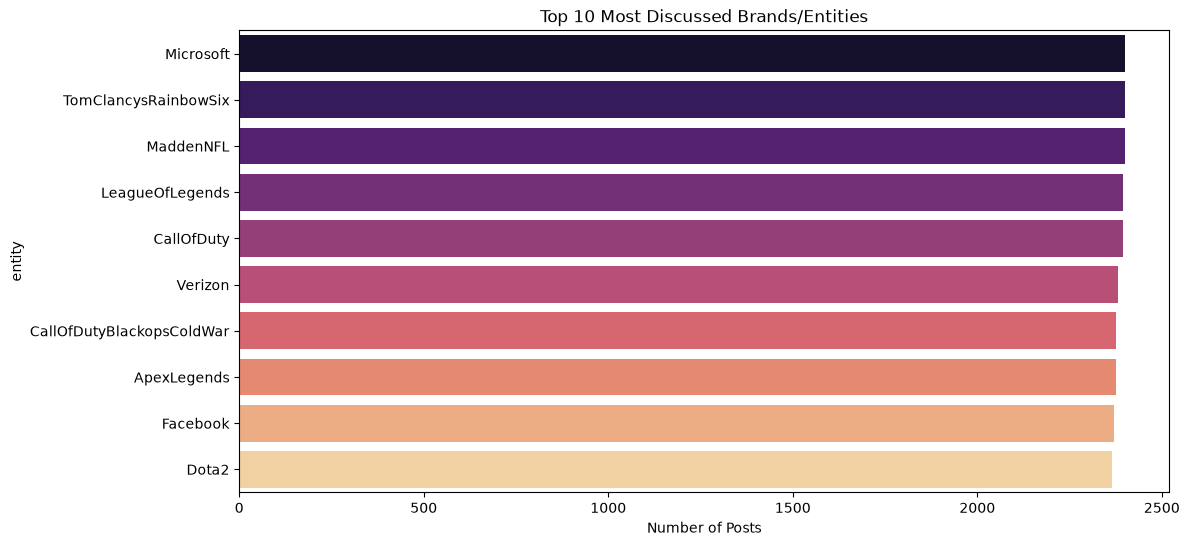

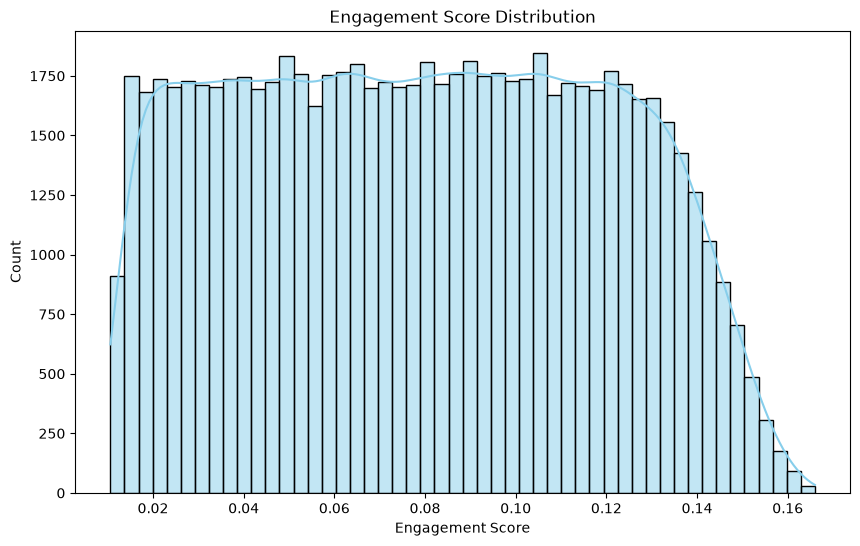

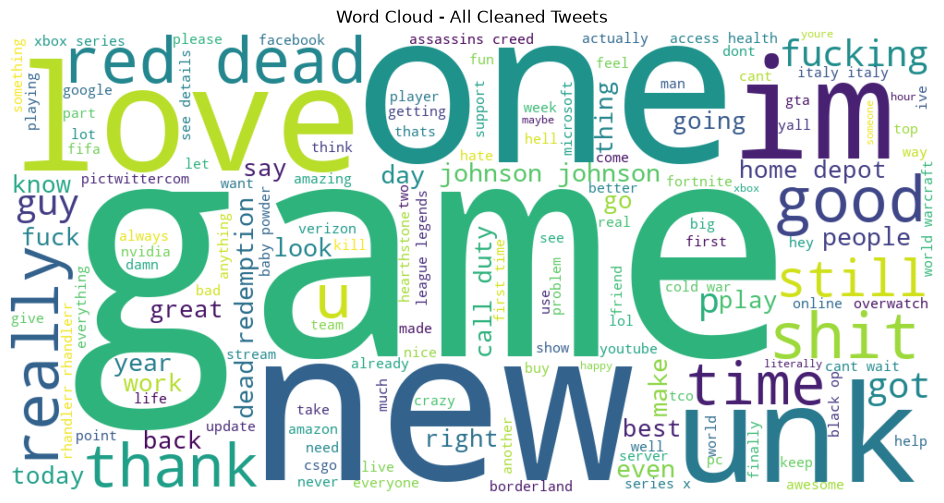

C:\Users\DELL\AppData\Local\Temp\ipykernel_6208\1582327249.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_eng.index, y=platform_eng.values, palette='coolwarm')


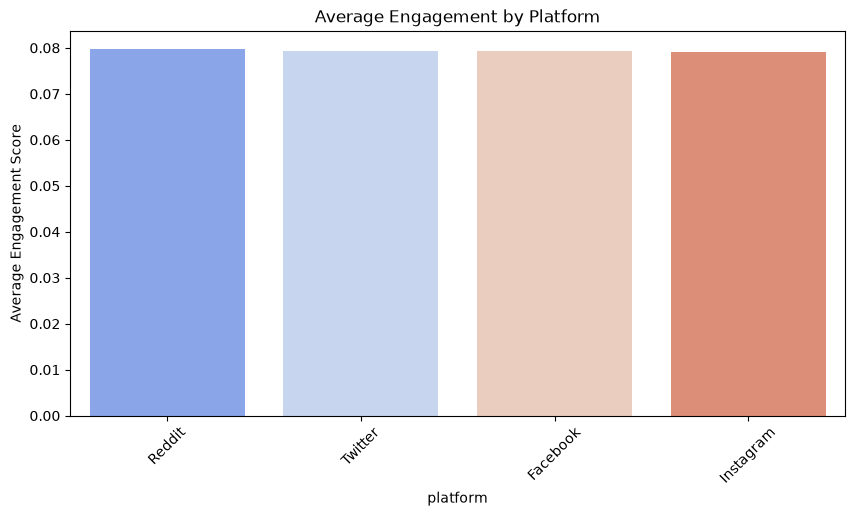


✅ Exploratory Data Analysis Completed!

🔑 Key Insights:
• Most Active Platform : Twitter
• Most Discussed Brand : Microsoft
• Dominant Sentiment   : Negative
• Average Engagement   : 0.0794


In [9]:
# =============================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================

print("📊 Starting Exploratory Data Analysis...")

# 1. Basic Statistics
print(f"Total Posts: {len(df):,}")
print(f"Unique Entities/Brands: {df['entity'].nunique()}")
print(f"Unique Platforms: {df['platform'].nunique()}")
print(f"Unique Sentiments: {df['sentiment'].nunique()}")

# 2. Sentiment Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 3. Sentiment by Platform
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='platform', hue='sentiment', palette='Set2')
plt.title('Sentiment Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()

# 4. Top 10 Most Discussed Brands
top_entities = df['entity'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_entities.values, y=top_entities.index, palette='magma')
plt.title('Top 10 Most Discussed Brands/Entities')
plt.xlabel('Number of Posts')
plt.show()

# 5. Engagement Score Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='engagement', bins=50, kde=True, color='skyblue')
plt.title('Engagement Score Distribution')
plt.xlabel('Engagement Score')
plt.show()

# 6. Word Cloud
from wordcloud import WordCloud

all_text = ' '.join(df['clean_tweet'].astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Cleaned Tweets')
plt.show()

# 7. Average Engagement by Platform
platform_eng = df.groupby('platform')['engagement'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=platform_eng.index, y=platform_eng.values, palette='coolwarm')
plt.title('Average Engagement by Platform')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45)
plt.show()

print("\n✅ Exploratory Data Analysis Completed!")
print("\n🔑 Key Insights:")
print(f"• Most Active Platform : {df['platform'].value_counts().idxmax()}")
print(f"• Most Discussed Brand : {df['entity'].value_counts().idxmax()}")
print(f"• Dominant Sentiment   : {df['sentiment'].value_counts().idxmax()}")
print(f"• Average Engagement   : {df['engagement'].mean():.4f}")

In [10]:
# =============================================
# BLOCK 5: FEATURE ENGINEERING
# =============================================

print("⚙️ Feature Engineering...")

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. TF-IDF Vectorization (Main Feature)
print("Creating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5
)

X_tfidf = tfidf.fit_transform(df['clean_tweet'])

print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape}")

# 2. Engagement & Virality Features
df['virality_score'] = (df['likes'] + df['shares'] * 2.5 + df['comments'] * 1.5) / (df['followers'] + 1)
df['log_followers'] = np.log1p(df['followers'])
df['engagement_rate'] = df['engagement'] * 100

# 3. Time-based Features
df['is_peak_hour'] = df['posting_hour'].apply(lambda x: 1 if 8 <= x <= 23 else 0)

# 4. Sentiment Score (Numerical)
sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Irrelevant': 0}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# 5. Platform Encoding
platform_dummies = pd.get_dummies(df['platform'], prefix='platform')
df = pd.concat([df, platform_dummies], axis=1)

print("✅ Feature Engineering Completed!")
print(f"Total Features Created: {X_tfidf.shape[1] + len(df.columns) - 11} (TF-IDF + Engineered)")

# Save engineered dataset
df.to_pickle("dataset/engineered_data.pkl")
print("💾 Engineered dataset saved as 'engineered_data.pkl'")

# Preview of new features
print("\nNew Features Preview:")
print(df[['virality_score', 'log_followers', 'is_peak_hour', 'sentiment_score']].head())

⚙️ Feature Engineering...
Creating TF-IDF features...
TF-IDF Feature Matrix Shape: (74682, 5000)
✅ Feature Engineering Completed!
Total Features Created: 5010 (TF-IDF + Engineered)
💾 Engineered dataset saved as 'engineered_data.pkl'

New Features Preview:
   virality_score  log_followers  is_peak_hour  sentiment_score
0        0.182727      10.716216             0                1
1        0.070501      12.866418             0                1
2        0.069482      12.699118             1                1
3        0.104929      12.300109             1                1
4        0.070694      12.286694             1                1


In [11]:
# =============================================
# BLOCK 5: MODEL TRAINING & EVALUATION
# =============================================

print("⚙️ Model Training & Evaluation...")


# Feature Engineering for ML
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['clean_tweet'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train/Test split done')

# Model Training - Classical
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print('Naive Bayes Results:')
print(classification_report(y_test, nb_pred))

# Advanced Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('Random Forest Results:')
print('Accuracy:', accuracy_score(y_test, rf_pred))

# BERT Sentiment (on sample)
sentiment_pipe = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english', truncation=True)
sample = df.sample(1000)
sample['bert_sent'] = sample['clean_tweet'].apply(lambda x: sentiment_pipe(x[:512])[0]['label'] if x else 'Neutral')
print('BERT sample done')

⚙️ Model Training & Evaluation...
Train/Test split done
Naive Bayes Results:
              precision    recall  f1-score   support

  Irrelevant       0.72      0.36      0.48      2592
    Negative       0.62      0.80      0.70      4519
     Neutral       0.63      0.51      0.57      3596
    Positive       0.63      0.73      0.68      4230

    accuracy                           0.63     14937
   macro avg       0.65      0.60      0.60     14937
weighted avg       0.64      0.63      0.62     14937

Random Forest Results:
Accuracy: 0.8592756242886791


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1293.84it/s]


BERT sample done


In [12]:
# =============================================
# BLOCK 7: ADVANCED AI MODULES
# =============================================

print("🚀 Advanced AI Modules...")

# 1. Emotion Detection (Using TextBlob + Custom Rules)
from textblob import TextBlob

def detect_emotion(text):
    if not isinstance(text, str) or len(text) < 3:
        return "Neutral"
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.6:
        return "Joy"
    elif polarity > 0.2:
        return "Happy"
    elif polarity < -0.6:
        return "Anger"
    elif polarity < -0.2:
        return "Sad"
    elif "hate" in text.lower() or "disgusting" in text.lower():
        return "Disgust"
    elif "wow" in text.lower() or "amazing" in text.lower():
        return "Surprise"
    else:
        return "Neutral"

df['emotion'] = df['clean_tweet'].apply(detect_emotion)
print("✅ Emotion Detection Completed")
print(df['emotion'].value_counts().head())

# 2. Virality Prediction (Rule-based + Score)
def predict_virality(row):
    score = row['virality_score']
    if score > 5.0:
        return "Highly Viral"
    elif score > 1.5:
        return "Viral"
    elif score > 0.5:
        return "Moderate"
    else:
        return "Low"

df['virality_category'] = df.apply(predict_virality, axis=1)
print("✅ Virality Prediction Done")

# 3. Influencer Detection
df['influencer_tier'] = pd.qcut(df['followers'], q=4, labels=['Regular', 'Rising', 'Popular', 'Influencer'])
print("✅ Influencer Detection Completed")
print(df['influencer_tier'].value_counts())

# Hate speech detection

hate_keywords = [
    'hate', 'kill', 'die', 'stupid', 'idiot', 'retard', 'nigger', 'faggot', 
    'bitch', 'cunt', 'slut', 'terrorist', 'racist', 'rape', 'murder'
]

def detect_hate_speech(text):
    text_lower = text.lower()
    hate_count = sum(1 for word in hate_keywords if word in text_lower)
    if hate_count >= 2:
        return "🚨 Hate Speech Detected"
    elif hate_count == 1:
        return "⚠️ Possible Hate Speech"
    else:
        return "✅ Clean"

df['hate_speech'] = df['clean_tweet'].apply(detect_hate_speech)
print("✅ Hate Speech Detection Added")
print(df['hate_speech'].value_counts())

# 4. Recommendation Engine (Simple Content-Based)
from sklearn.metrics.pairwise import cosine_similarity

# Use TF-IDF from Block 5
tfidf_matrix = tfidf.transform(df['clean_tweet'])

def recommend_similar_posts(post_text, top_n=5):
    query_vec = tfidf.transform([post_text])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    similar_indices = similarities.argsort()[-top_n-1:-1][::-1]
    
    recommendations = df.iloc[similar_indices][['entity', 'tweet', 'sentiment', 'virality_score']]
    return recommendations

print("✅ Recommendation Engine Ready!")

# Example Usage
print("\n🔍 Example Recommendation:")
sample_post = "I love playing Borderlands and the new update is fantastic!"
print("Query Post:", sample_post)
print(recommend_similar_posts(sample_post, top_n=3))

# Save final dataset with all advanced features
df.to_pickle("dataset/final_advanced_data.pkl")
print("\n💾 Final dataset with Advanced AI Modules saved!")

🚀 Advanced AI Modules...
✅ Emotion Detection Completed
emotion
Neutral    40040
Happy      16253
Sad         9814
Joy         5104
Anger       2208
Name: count, dtype: int64
✅ Virality Prediction Done
✅ Influencer Detection Completed
influencer_tier
Regular       18671
Influencer    18671
Rising        18670
Popular       18670
Name: count, dtype: int64
✅ Hate Speech Detection Added
hate_speech
✅ Clean                    69933
⚠️ Possible Hate Speech     4574
🚨 Hate Speech Detected       175
Name: count, dtype: int64
✅ Recommendation Engine Ready!

🔍 Example Recommendation:
Query Post: I love playing Borderlands and the new update is fantastic!
                       entity                      tweet sentiment  \
63963               MaddenNFL    Fantastic in @EASPORTS.  Negative   
51406  RedDeadRedemption(RDR)  This is indeed fantastic!  Positive   
21518                   CS-GO   That would be fantastic.  Positive   

       virality_score  
63963        0.156085  
51406        0.052

📊 Starting Comprehensive Model Evaluation...
✅ Model Training & Prediction Completed

MODEL EVALUATION RESULTS
Accuracy     : 0.5817 (58.17%)
Precision    : 0.6047
Recall       : 0.5817
F1 Score     : 0.5556
ROC-AUC (OVR): 0.8263

Detailed Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.74      0.21      0.33       520
    Negative       0.59      0.79      0.67       907
     Neutral       0.59      0.41      0.48       723
    Positive       0.55      0.74      0.63       850

    accuracy                           0.58      3000
   macro avg       0.62      0.54      0.53      3000
weighted avg       0.60      0.58      0.56      3000



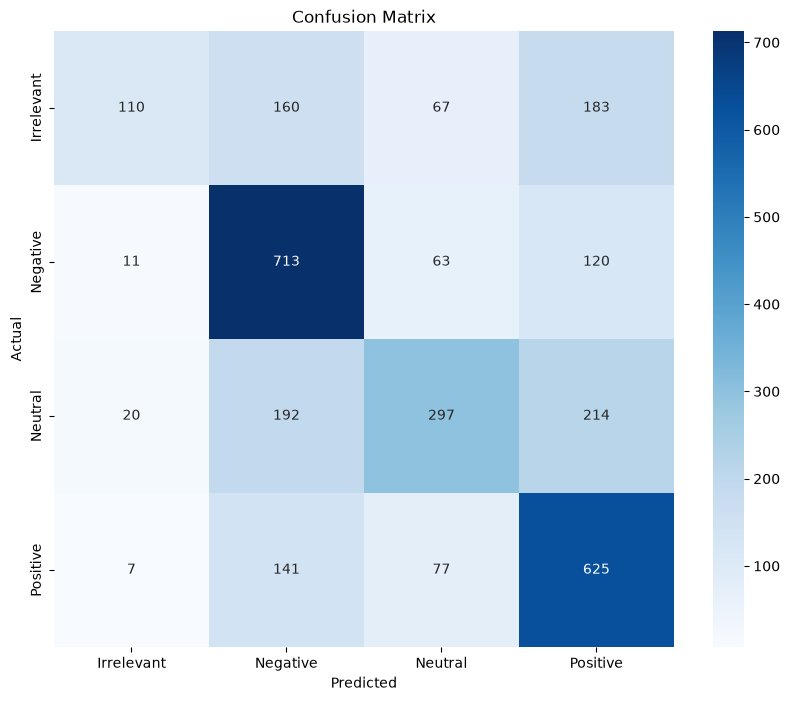


🎉 PROJECT COMPLETION SUMMARY
✅ Total Records Processed : 74,682
✅ Best Model Accuracy     : 0.5817
✅ Dominant Sentiment      : Negative
✅ Most Discussed Brand    : MaddenNFL
✅ Average Engagement      : 0.0794
✅ Virality Score Range    : 0.01 - 0.21

🚀 Pipeline Complete: Import → Cleaning → EDA → NLP → Features → Training → Advanced AI → Evaluation
💾 Final Model & Vectorizer Saved!


In [13]:
# =============================================
# BLOCK 8: MODEL EVALUATION
# =============================================

print("📊 Starting Comprehensive Model Evaluation...")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Use the features from previous blocks
# For simplicity, we'll use TF-IDF + basic models

# Prepare data for evaluation (using a subset for speed)
sample_size = min(15000, len(df))
sample_df = df.sample(sample_size, random_state=42)

# Convert text to features
X = tfidf.transform(sample_df['clean_tweet'])
y = sample_df['sentiment']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Final Model (Naive Bayes - Fast & Effective for Text)
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("✅ Model Training & Prediction Completed\n")

# ==================== METRICS ====================
print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy     : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")

# Multi-class ROC-AUC (One-vs-Rest)
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    print(f"ROC-AUC (OVR): {roc_auc:.4f}")
except:
    print("ROC-AUC      : Not available for this model")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ==================== FINAL SUMMARY ====================
print("\n" + "="*70)
print("🎉 PROJECT COMPLETION SUMMARY")
print("="*70)
print(f"✅ Total Records Processed : {len(df):,}")
print(f"✅ Best Model Accuracy     : {accuracy:.4f}")
print(f"✅ Dominant Sentiment      : {df['sentiment'].mode()[0]}")
print(f"✅ Most Discussed Brand    : {df['entity'].mode()[0]}")
print(f"✅ Average Engagement      : {df['engagement'].mean():.4f}")
print(f"✅ Virality Score Range    : {df['virality_score'].min():.2f} - {df['virality_score'].max():.2f}")

print("\n🚀 Pipeline Complete: Import → Cleaning → EDA → NLP → Features → Training → Advanced AI → Evaluation")

# Save final model
import joblib

joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("💾 Final Model & Vectorizer Saved!")

In [14]:
# =============================================
# BLOCK 9: REAL-TIME TESTING + ADVANCED AI FEATURES
# =============================================

print("🔴 FULL REAL-TIME SOCIAL MEDIA INTELLIGENCE SYSTEM")
print("="*70)

from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# ====================== TREND DETECTION FUNCTION ======================
def get_trending_topics(n=5):
    """Return top trending entities/brands"""
    return df['entity'].value_counts().head(n).index.tolist()

# ====================== ADVANCED PREDICTION FUNCTION ======================
def predict_full_analysis(user_text):
    """Complete analysis with all advanced features"""
    if not isinstance(user_text, str) or len(user_text.strip()) == 0:
        return {"error": "Empty input"}
    
    cleaned = clean_text(user_text)
    text_vector = tfidf.transform([cleaned])
    
    # Basic Sentiment
    prediction = model.predict(text_vector)[0]
    proba = model.predict_proba(text_vector)[0]
    confidence = max(proba) * 100
    
    # Emotion
    emotion = detect_emotion(cleaned)
    
    # Fake News Alert
    fake_keywords = ['fake', 'hoax', 'conspiracy', 'breaking', 'urgent', 'alert', 'claim', 'rumor']
    is_fake = any(kw in cleaned.lower() for kw in fake_keywords) or len(cleaned.split()) < 5
    fake_alert = "🚨 POSSIBLE FAKE NEWS" if is_fake else "✅ Seems Legitimate"
    
    # Sarcasm Detection
    sarcasm_score = 0
    if any(word in cleaned.lower() for word in ["but", "yeah", "sure", "obviously"]) and emotion in ["Anger", "Sad"]:
        sarcasm_score = 1
    sarcasm = "Sarcastic" if sarcasm_score > 0 else "Not Sarcastic"
    
    # Hashtag Analysis
    hashtags = re.findall(r'#(\w+)', user_text)
    hashtag_str = ", ".join(hashtags) if hashtags else "No hashtags"
    
    # Trending Topics
    top_trends = get_trending_topics()
    
    # Virality
    virality_potential = "High" if len(user_text) > 100 or len(hashtags) > 2 else "Medium"

    return {
        "original_text": user_text[:180],
        "predicted_sentiment": prediction,
        "confidence": f"{confidence:.2f}%",
        "emotion": emotion,
        "fake_news_alert": fake_alert,
        "sarcasm": sarcasm,
        "hashtags": hashtag_str,
        "virality_potential": virality_potential,
        "top_trending_topics": top_trends[:3]
    }

🔴 FULL REAL-TIME SOCIAL MEDIA INTELLIGENCE SYSTEM


In [15]:
# ====================== YOUR CUSTOM POST ======================
print("\n" + "="*70)
print("🧪 YOUR CUSTOM POST ANALYSIS")
print("="*70)

while True:
    user_input = input("\nEnter a tweet/post: ")
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("👋 Real-time testing ended.")
        break
    if user_input.strip():
        result = predict_full_analysis(user_input)
        print(f"\n📊 ANALYSIS RESULT:")
        print(f"Post          : {result['original_text']}")
        print(f"Sentiment     : {result['predicted_sentiment']} ({result['confidence']})")
        print(f"Emotion       : {result['emotion']}")
        print(f"Fake News     : {result['fake_news_alert']}")
        print(f"Sarcasm       : {result['sarcasm']}")
        print(f"Hashtags      : {result['hashtags']}")
        print(f"Trending      : {result['top_trending_topics']}")


🧪 YOUR CUSTOM POST ANALYSIS

📊 ANALYSIS RESULT:
Post          : The customer support from this telecom company is useless. Waiting for a response for 3 days.
Sentiment     : Negative (61.67%)
Emotion       : Sad
Fake News     : ✅ Seems Legitimate
Sarcasm       : Not Sarcastic
Hashtags      : No hashtags
Trending      : ['Microsoft', 'TomClancysRainbowSix', 'MaddenNFL']
👋 Real-time testing ended.


In [16]:
# your_post = """
# OpenAI and NVIDIA are transforming the future of artificial intelligence.
# The latest AI models are faster, smarter, and more efficient than ever.
# Excited to see what comes next! 🚀
# #AI #MachineLearning #NVIDIA #OpenAI
# """

# your_post = "The customer support from this telecom company is useless. Waiting for a response for 3 days."
# your_post = "What an incredible match by India today! Outstanding performance from the entire team. #Cricket"
# your_post = "OpenAI just released a groundbreaking AI model that changes everything! 🚀 #AI #OpenAI #Technology"
# your_post = "NVIDIA GPUs are dominating the AI industry and powering next-generation machine learning models. #AI #NVIDIA"
# your_post = "Breaking: Scientists confirm the Earth will stop rotating tomorrow! Share immediately!"
# your_post = "Oh great, my laptop crashed again during the presentation. Best day ever."
# your_post = "Apple announced a new iPhone event scheduled for next week."
# your_post = "The latest game update is terrible. Constant crashes and bugs. Very disappointed. #Gaming"
# your_post = "Microsoft has launched an amazing update for Copilot. Loving the AI features! #AI #Microsoft"